# Unmasking Clustering: Under the Hood of K-Means
**A 5-Minute Deep Dive**

While libraries like `scikit-learn` make clustering a one-liner, understanding the underlying mechanics—specifically the **Expectation-Maximization (EM) algorithm**—is crucial for knowing when an algorithm will succeed or fail. 

Today, we will build K-Means from scratch to visualize its engine, and then explore advanced concepts regarding its geometric limitations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import DBSCAN

# Set a clean visual style for our presentation
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

### 1. The Raw Data
Let's generate synthetic, unlabeled data. To the computer, this is just a matrix of coordinates.

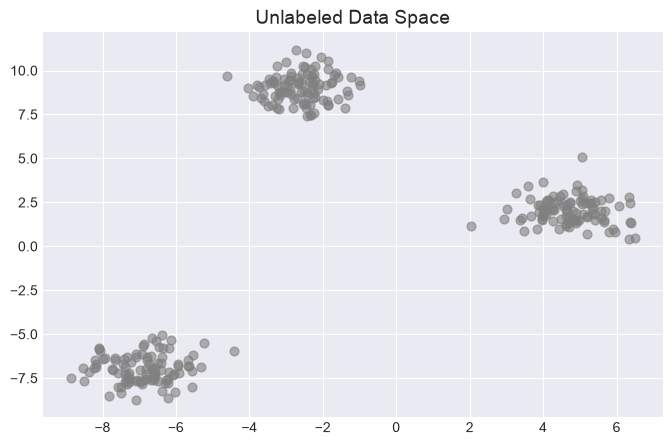

In [2]:
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=40, color='gray', alpha=0.6)
plt.title("Unlabeled Data Space", fontsize=14)
plt.show()

### 2. Step 1: Initialization (The Forgy Method)
K-Means requires us to define $K$ (the number of clusters). We initialize by randomly selecting $K$ data points to act as our starting **centroids**. 

*Advanced Note: Modern implementations use **K-Means++**, which probabilistically spreads out the initial centroids to prevent falling into local minima.*

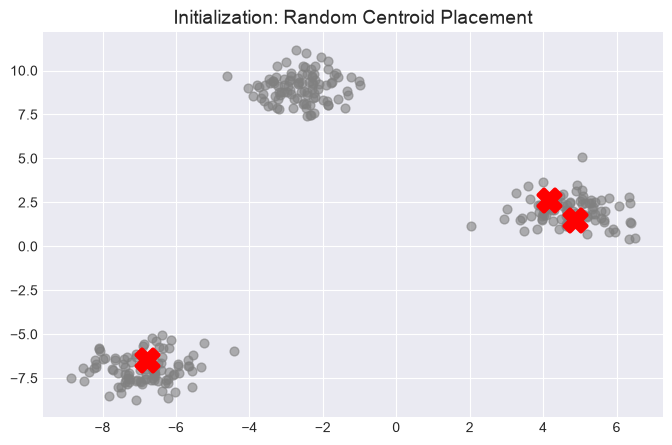

In [3]:
K = 3
random_indices = np.random.permutation(X.shape[0])
centroids = X[random_indices[:K]]

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=40, color='gray', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, marker='X', color='red', linewidths=3)
plt.title("Initialization: Random Centroid Placement", fontsize=14)
plt.show()

### 3. Step 2: The "Expectation" Step (Assignment)
We calculate the Euclidean distance from every single point to every centroid. Points are assigned to whichever centroid is closest. 

Mathematically, this partitions the space into a **Voronoi tessellation**.

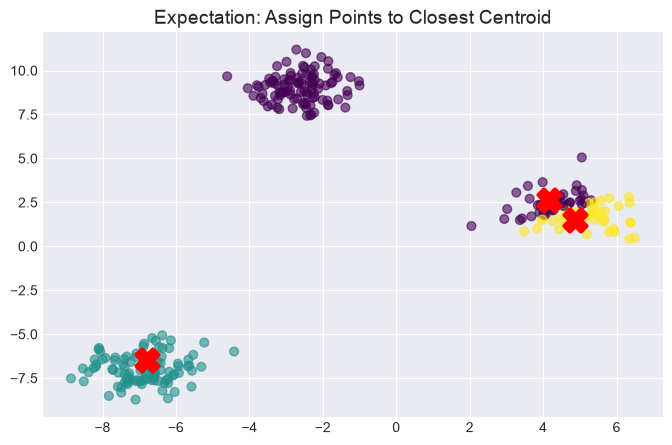

In [4]:
# Vectorized distance calculation: (300, 1, 2) - (1, 3, 2) -> (300, 3, 2)
distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
labels = np.argmin(distances, axis=1)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, marker='X', color='red', linewidths=3)
plt.title("Expectation: Assign Points to Closest Centroid", fontsize=14)
plt.show()

### 4. Step 3: The "Maximization" Step (Update)
Now that points are assigned, the old centroids are incorrect. We update each centroid's position to be the literal mathematical **mean (center of mass)** of all points currently assigned to it.

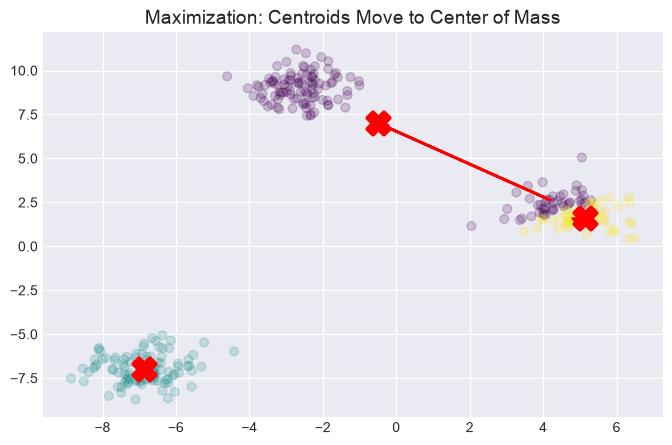

In [5]:
# Calculate new centroids
new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(K)])

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.2)

# Draw movement arrows to show the algorithm "learning"
for i in range(K):
    plt.arrow(centroids[i, 0], centroids[i, 1], 
              new_centroids[i, 0] - centroids[i, 0], 
              new_centroids[i, 1] - centroids[i, 1], 
              head_width=0.2, color='red', linewidth=2, length_includes_head=True)
    
plt.scatter(new_centroids[:, 0], new_centroids[:, 1], s=250, marker='X', color='red', linewidths=3)
plt.title("Maximization: Centroids Move to Center of Mass", fontsize=14)
plt.show()

# Save for next iteration
centroids = new_centroids

### 5. Convergence
The algorithm repeats the E and M steps until the centroids stop moving. At that point, convergence is reached and the sum of squared distances (inertia) is minimized.

### 6. Advanced Concept: The Convexity Assumption & DBSCAN
Because K-Means uses Euclidean distance from a central point, it **assumes clusters are spherical and convex**. If your data has complex topological structures (like nested circles or curves), K-Means will fail catastrophically.

To solve this, we shift paradigms to **Density-Based Spatial Clustering of Applications with Noise (DBSCAN)**. Instead of finding geometric centers, DBSCAN walks through the data space, linking points that are densely packed together.

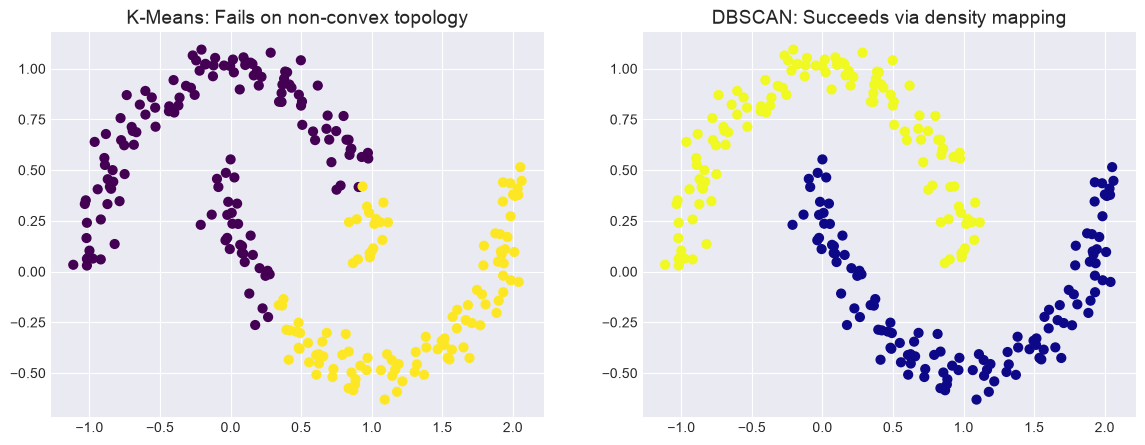

In [6]:
# Generate non-spherical data
X_moons, _ = make_moons(n_samples=250, noise=0.07, random_state=42)

# 1. How K-Means sees it (Forced Spheres)
distances_moons = np.linalg.norm(X_moons[:, np.newaxis] - np.array([[0, 0.5], [1, -0.5]]), axis=2)
labels_kmeans = np.argmin(distances_moons, axis=1)

# 2. How DBSCAN sees it (Density connectivity)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_moons)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans, cmap='viridis', s=40)
ax1.set_title("K-Means: Fails on non-convex topology", fontsize=14)

ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_dbscan, cmap='plasma', s=40)
ax2.set_title("DBSCAN: Succeeds via density mapping", fontsize=14)

plt.show()